# How a Decision Tree Works (Regression)

A decision tree regressor approximates a function by **recursively splitting** the input space into regions.

In **1D**, those regions are just **intervals** on the x-axis. For each interval (a **leaf**), the tree predicts a **constant value** (typically the mean target value of the training points that fell into that leaf).

So the prediction looks like a **step function** that becomes more detailed as the tree depth increases.

## What you should notice in the plots

- Each **vertical dashed line** is a learned split threshold.
- Between two split thresholds, the prediction is **constant** (one leaf).
- Increasing `max_depth` increases the number of leaves and lets the tree capture more non-linearity (but can overfit noise).

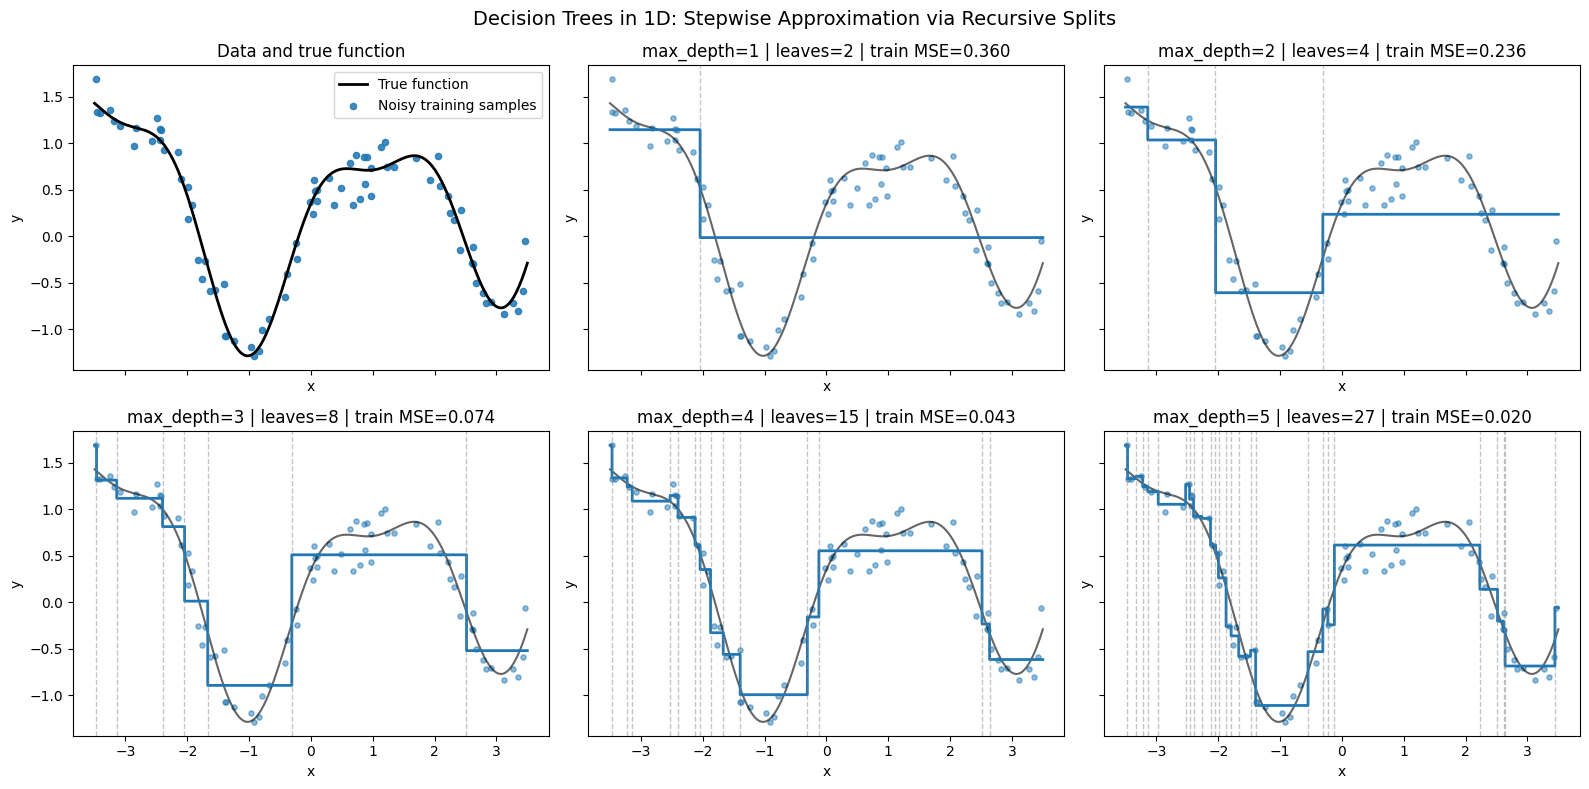

In [1]:
# Single-cell demo: stepwise approximation of a non-linear function with decision trees

import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor

# --- 1) Create a non-linear target function and noisy samples ---
rng = np.random.default_rng(7)

def f(x: np.ndarray) -> np.ndarray:
    # Smooth but non-linear (mix of sinusoids + a mild quadratic trend)
    return np.sin(1.5 * x) + 0.35 * np.cos(3.0 * x) + 0.06 * (x ** 2)

n_train = 80
x_train = rng.uniform(-3.5, 3.5, size=n_train)
x_train.sort()
y_train = f(x_train) + rng.normal(0.0, 0.18, size=n_train)

X_train = x_train.reshape(-1, 1)

x_grid = np.linspace(-3.5, 3.5, 1200)
X_grid = x_grid.reshape(-1, 1)
y_true_grid = f(x_grid)

# --- 2) Fit trees with increasing depth (showing stepwise refinement) ---
depths = [1, 2, 3, 4, 5]

def split_thresholds_1d(tree: DecisionTreeRegressor) -> np.ndarray:
    # Extract all threshold values used in internal nodes for feature 0
    t = tree.tree_
    is_internal = t.feature >= 0
    thresholds = t.threshold[is_internal]
    thresholds = thresholds[np.isfinite(thresholds)]
    return np.unique(np.sort(thresholds))

# --- 3) Plot true function, data, and approximations ---
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True, sharey=True)
axes = axes.ravel()

# Panel 0: data + true function
ax0 = axes[0]
ax0.plot(x_grid, y_true_grid, color='black', linewidth=2.0, label='True function')
ax0.scatter(x_train, y_train, s=20, alpha=0.85, label='Noisy training samples')
ax0.set_title('Data and true function')
ax0.legend(loc='best')

# Panels 1..5: tree approximations for each depth
for i, depth in enumerate(depths, start=1):
    
    model = DecisionTreeRegressor(max_depth=depth, random_state=0)
    model.fit(X_train, y_train)

    y_pred_grid = model.predict(X_grid)
    mse_train = np.mean((model.predict(X_train) - y_train) ** 2)

    # True function (reference) + stepwise prediction
    ax = axes[i]
    ax.plot(x_grid, y_true_grid, color='black', linewidth=1.5, alpha=0.6)
    ax.step(x_grid, y_pred_grid, where='mid', linewidth=2.0, label='Tree prediction')
    ax.scatter(x_train, y_train, s=14, alpha=0.5)

    # Visualize the learned split positions
    for thr in split_thresholds_1d(model):
        ax.axvline(thr, color='gray', linestyle='--', linewidth=1.0, alpha=0.45)

    ax.set_title(f'max_depth={depth} | leaves={model.get_n_leaves()} | train MSE={mse_train:.3f}')
    
for ax in axes:
    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig.suptitle('Decision Trees in 1D: Stepwise Approximation via Recursive Splits', fontsize=14)
fig.tight_layout()
plt.show()

In [2]:
t = model.tree_
t

In [3]:
t.feature

array([ 0,  0,  0, -2,  0,  0, -2, -2, -2,  0,  0,  0, -2, -2,  0, -2, -2,
        0,  0, -2, -2, -2,  0,  0,  0,  0, -2, -2,  0, -2, -2,  0,  0, -2,
       -2,  0, -2, -2,  0,  0,  0, -2, -2,  0, -2, -2,  0,  0, -2, -2,  0,
       -2, -2], dtype=int64)

In [4]:
is_internal = t.feature >= 0
thresholds = t.threshold[is_internal]
thresholds

array([-2.04536235, -3.1388222 , -3.46850157, -3.22132194, -3.33383989,
       -2.39864409, -2.53023481, -2.97238457, -2.46519113, -2.12446892,
       -2.26585031, -0.31051185, -1.67135888, -1.87330097, -1.99390543,
       -1.79522389, -1.39794773, -1.47492838, -0.55015883,  2.51471376,
       -0.12317064, -0.23050658,  2.23148274,  2.64043212,  2.61670661,
        3.4456116 ])

In [5]:
len(thresholds)

26

In [6]:
model.get_n_leaves()

27